# Demo Apriori cho Đồ án 2

Notebook này minh họa nhanh các phần **bắt buộc** của đồ án: ví dụ tay trên dữ liệu nhỏ, kiểm tra tình huống đặc biệt, chạy cài đặt Apriori from scratch, và xem lại các kết quả thực nghiệm đã sinh trong thư mục `docs/`.

- Chương 2: minh họa trên `toy1.txt` và `toy2_special.txt`
- Chương 3: chạy Apriori, đối chiếu support, so sánh bản tối ưu với baseline
- Chương 4: tổng hợp benchmark datasets và hiển thị các biểu đồ đã xuất

> Lưu ý: notebook này hỗ trợ phần demo/reproducibility, **không thay thế báo cáo PDF học thuật**.


In [1]:
from pathlib import Path
import sys
import time

import pandas as pd
from IPython.display import Markdown, display, Image

# Tìm project root một cách an toàn dù notebook được mở từ đâu.
def find_repo_root(start: Path) -> Path:
    candidates = [start] + list(start.parents)
    for candidate in candidates:
        if (candidate / "src").exists() and (candidate / "data").exists():
            return candidate
    raise RuntimeError("Không tìm thấy thư mục gốc của project.")

ROOT = find_repo_root(Path.cwd().resolve())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.algorithm.apriori import apriori, apriori_baseline
from src.utils import load_transactions_spmf

TOY_DIR = ROOT / "data" / "toy"
BENCHMARK_DIR = ROOT / "data" / "benchmark"
DOCS_DIR = ROOT / "docs"

display(Markdown(f"**Project root:** `{ROOT}`"))
display(Markdown("**Các thư mục chính đã sẵn sàng:** `data/`, `src/`, `tests/`, `docs/`"))


**Project root:** `D:\Coding\Data mining\lab2 repo\Data-Mining-Lab-2`

**Các thư mục chính đã sẵn sàng:** `data/`, `src/`, `tests/`, `docs/`

## 1. Ví dụ cơ sở trên `toy1.txt`

Theo đề, nhóm cần có một ví dụ nhỏ 5-7 giao dịch và 5-6 item, trình bày từng bước và kiểm tra chéo kết quả. Cell dưới đây dùng đúng tập `toy1.txt` để hỗ trợ phần đó.


In [2]:
transactions = load_transactions_spmf(str(TOY_DIR / "toy1.txt"))
toy1_df = pd.DataFrame({
    "Transaction": [f"T{i}" for i in range(1, len(transactions) + 1)],
    "Items": [sorted(t) for t in transactions],
    "Length": [len(t) for t in transactions],
})

minsup_rel = 0.4
minsup_abs = int(minsup_rel * len(transactions))

display(toy1_df)
display(Markdown(f"**N = {len(transactions)} giao dịch**, chọn `minsup = {minsup_rel}` nên `minsup_count = {minsup_abs}`."))


,Transaction,Items,Length
0,T1,"[1, 3, 4]",3
1,T2,"[2, 3, 5]",3
2,T3,"[1, 2, 3, 5]",4
3,T4,"[2, 5]",2
4,T5,"[1, 2, 3, 4, 5]",5


**N = 5 giao dịch**, chọn `minsup = 0.4` nên `minsup_count = 2`.

In [3]:
frequent_itemsets = apriori(transactions, min_support=minsup_rel, use_bitarray=True)
rows = []
for itemset, support in sorted(frequent_itemsets.items(), key=lambda kv: (len(kv[0]), sorted(kv[0]))):
    rows.append({
        "k": len(itemset),
        "itemset": tuple(sorted(itemset)),
        "support": support,
        "support_ratio": round(support / len(transactions), 3),
    })

result_df = pd.DataFrame(rows)
display(Markdown(f"**Tổng số frequent itemsets tìm được:** `{len(result_df)}`"))
display(result_df)


**Tổng số frequent itemsets tìm được:** `19`

,k,itemset,support,support_ratio
0,1,"(1,)",3,0.6
1,1,"(2,)",4,0.8
2,1,"(3,)",4,0.8
3,1,"(4,)",2,0.4
4,1,"(5,)",4,0.8
5,2,"(1, 2)",2,0.4
6,2,"(1, 3)",3,0.6
7,2,"(1, 4)",2,0.4
8,2,"(1, 5)",2,0.4
9,2,"(2, 3)",3,0.6


## 2. Tình huống đặc biệt trên `toy2_special.txt`

Đây là bộ dữ liệu mà mọi giao dịch đều giống nhau. Với loại dữ liệu này, Apriori sẽ sinh ra toàn bộ các tập con không rỗng vì support của chúng đều đạt ngưỡng. Đây là ví dụ tốt để giải thích tại sao output size có thể bùng nổ khi dữ liệu dày đặc.


In [4]:
special_transactions = load_transactions_spmf(str(TOY_DIR / "toy2_special.txt"))
special_result = apriori(special_transactions, min_support=1, absolute=True)

special_df = pd.DataFrame({
    "itemset": [tuple(sorted(fs)) for fs in sorted(special_result, key=lambda x: (len(x), sorted(x)))],
    "support": [special_result[fs] for fs in sorted(special_result, key=lambda x: (len(x), sorted(x)))],
})

display(Markdown(f"**Số giao dịch:** `{len(special_transactions)}` | **Số frequent itemsets:** `{len(special_result)}`"))
display(special_df)


**Số giao dịch:** `5` | **Số frequent itemsets:** `7`

,itemset,support
0,"(1,)",5
1,"(2,)",5
2,"(3,)",5
3,"(1, 2)",5
4,"(1, 3)",5
5,"(2, 3)",5
6,"(1, 2, 3)",5


## 3. Kiểm tra cài đặt và tác dụng của tối ưu hóa

Phần cài đặt của repo có hai phiên bản: `apriori_baseline()` và `apriori(..., use_bitarray=True)`. Đoạn dưới vừa xác nhận kết quả giống nhau, vừa đo thời gian chạy để minh họa kỹ thuật tối ưu bằng bitarray.


In [5]:
toy3_transactions = load_transactions_spmf(str(TOY_DIR / "toy3.txt"))

start = time.perf_counter()
opt_result = apriori(toy3_transactions, min_support=3, absolute=True, use_bitarray=True)
opt_time = time.perf_counter() - start

start = time.perf_counter()
base_result = apriori_baseline(toy3_transactions, min_support=3, absolute=True)
base_time = time.perf_counter() - start

comparison_df = pd.DataFrame([
    {"version": "Optimized (bitarray)", "runtime_ms": round(opt_time * 1000, 3), "n_itemsets": len(opt_result)},
    {"version": "Baseline (horizontal scan)", "runtime_ms": round(base_time * 1000, 3), "n_itemsets": len(base_result)},
])

display(Markdown(f"**Kết quả hai phiên bản giống nhau:** `{opt_result == base_result}`"))
display(comparison_df)


**Kết quả hai phiên bản giống nhau:** `True`

,version,runtime_ms,n_itemsets
0,Optimized (bitarray),0.166,11
1,Baseline (horizontal scan),0.121,11


## 4. Dữ liệu benchmark và các biểu đồ đã sinh

Repo hiện có đủ 4 benchmark tối thiểu theo yêu cầu đề: `chess`, `mushroom`, `retail`, `T10I4D100K`. Cell dưới đây thống kê nhanh kích thước dữ liệu và hiển thị các hình đã được xuất trong thư mục `docs/`.


,dataset,path,transactions,items,avg_len,characteristic
0,chess,data/benchmark/chess.txt,3196,75,37.0,dense
1,mushroom,data/benchmark/mushroom.txt,8416,119,23.0,dense
2,retail,data/benchmark/retail.txt,88162,16470,10.3,sparse
3,T10I4D100K,data/benchmark/T10I4D100K.txt,100000,870,10.1,synthetic sparse


### `runtime_vs_minsup_toy3.png`

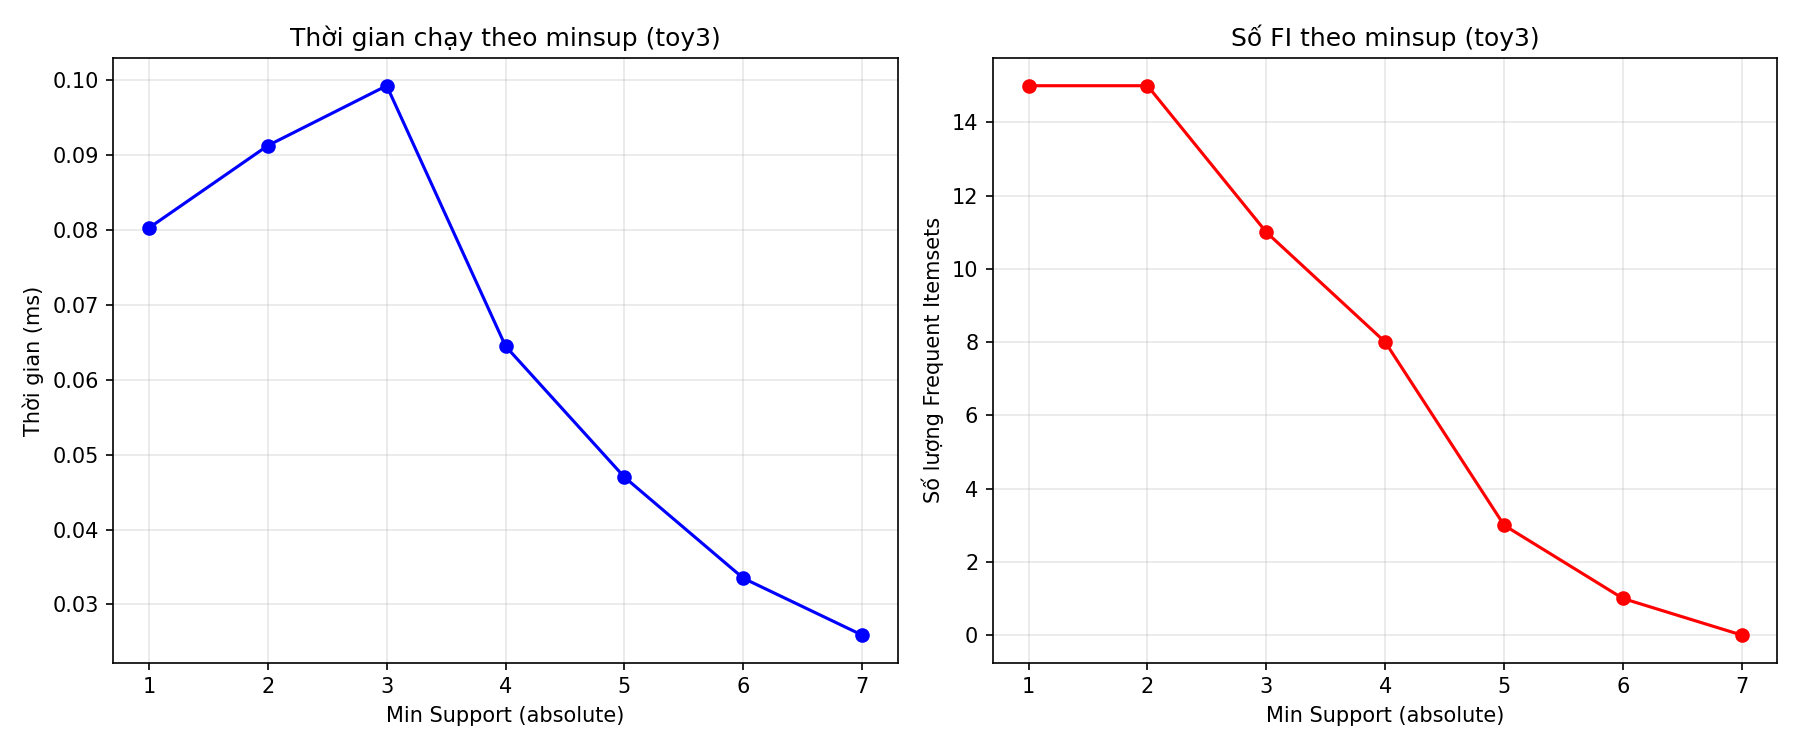

### `scalability_synthetic.png`

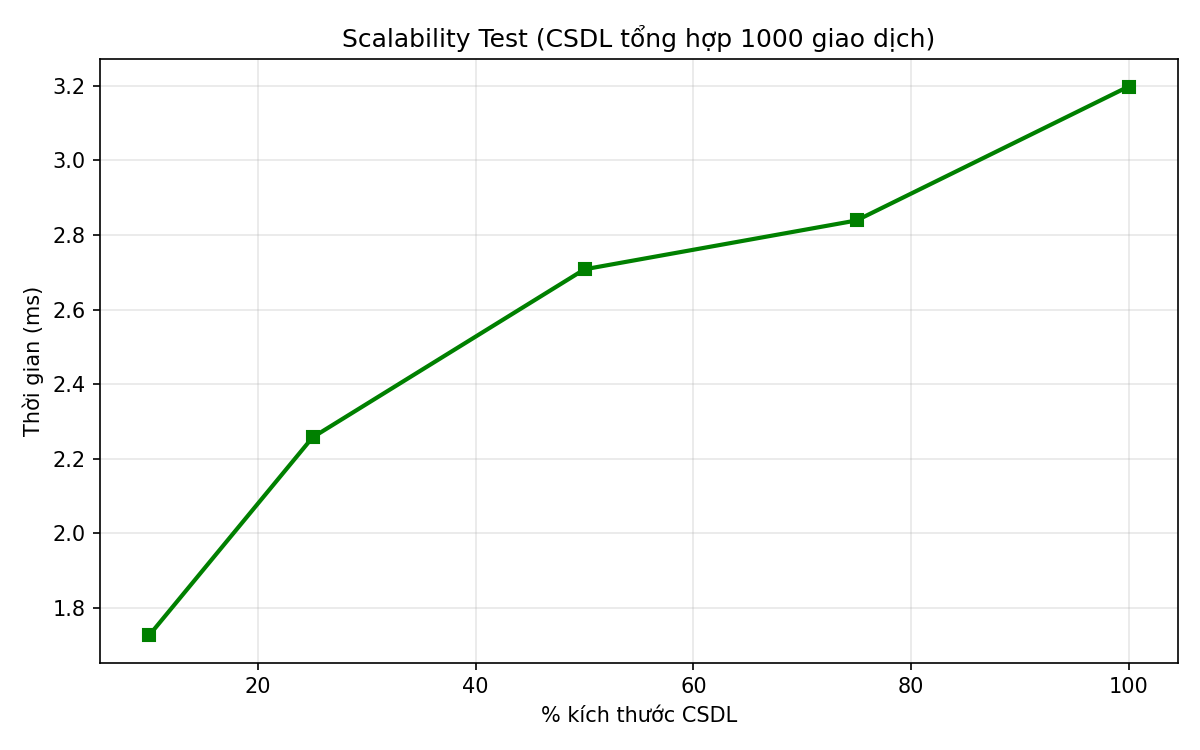

### `benchmark_chess.png`

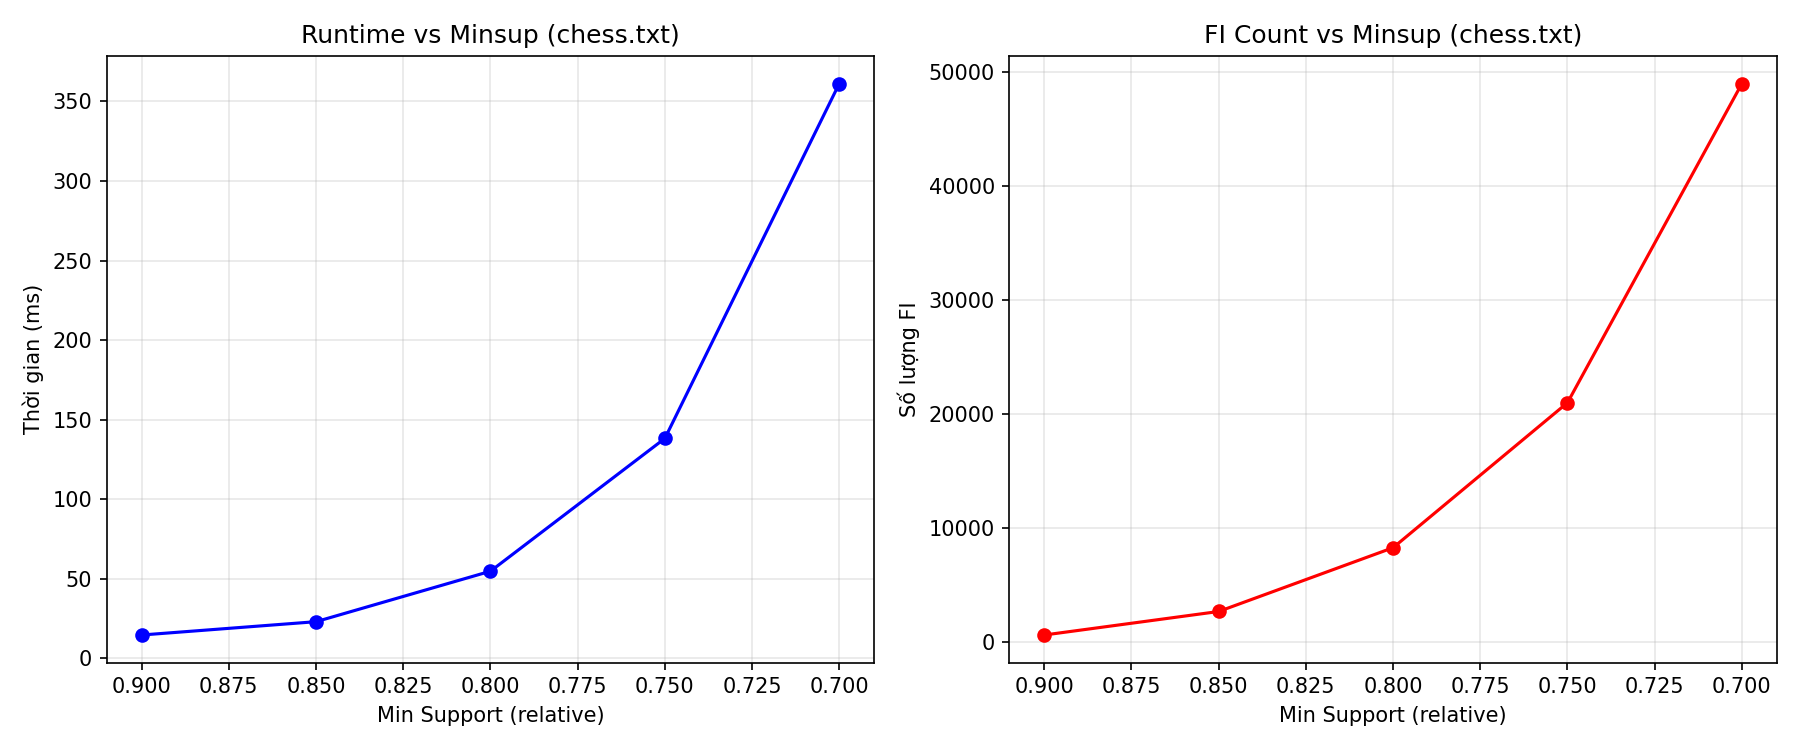

### `benchmark_mushroom.png`

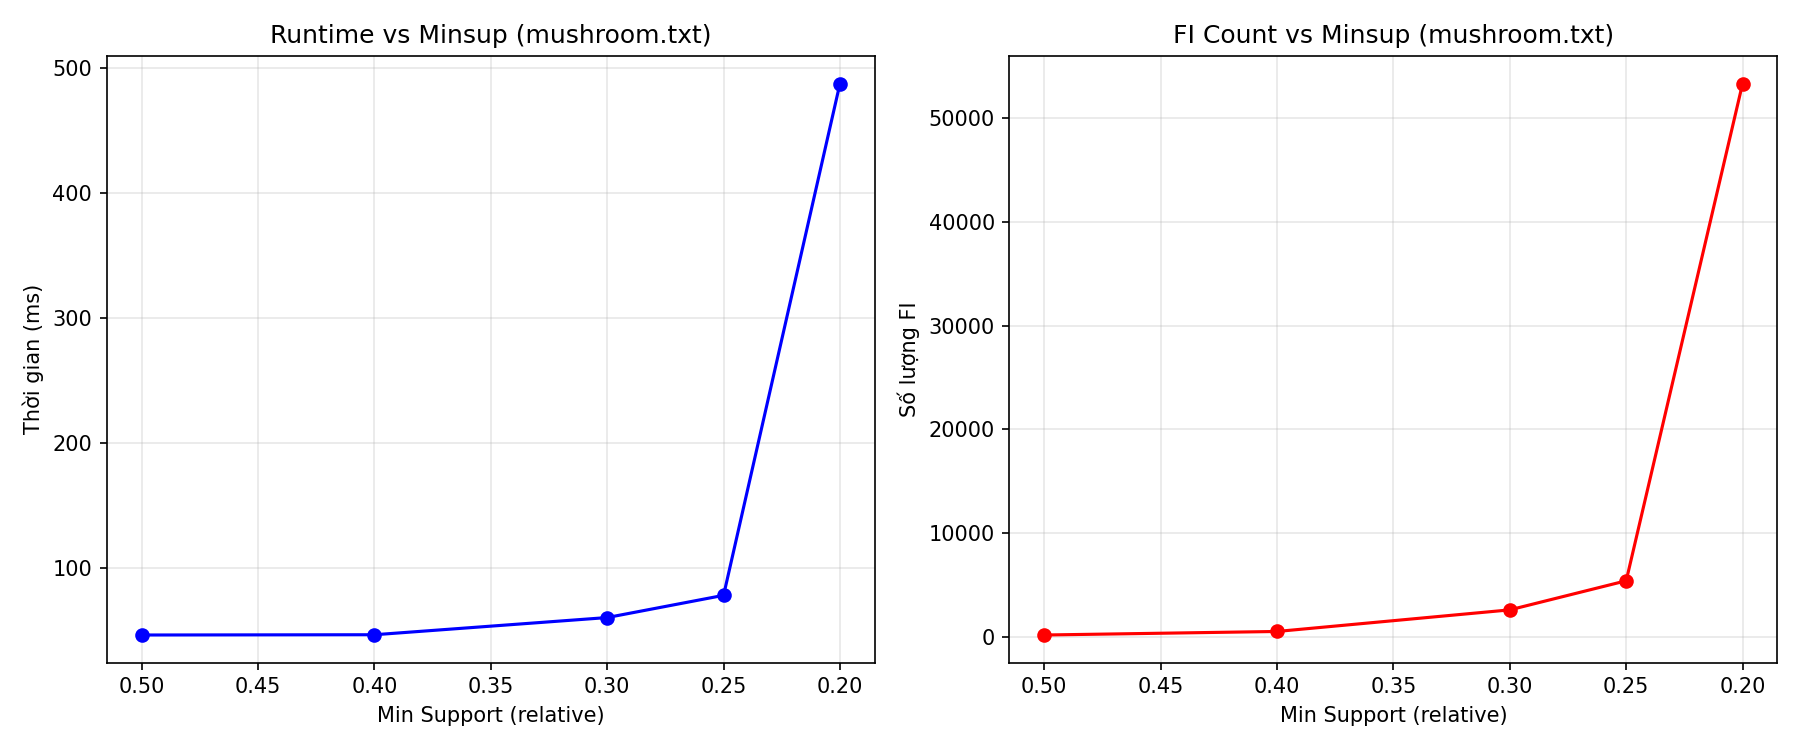

### `benchmark_retail.png`

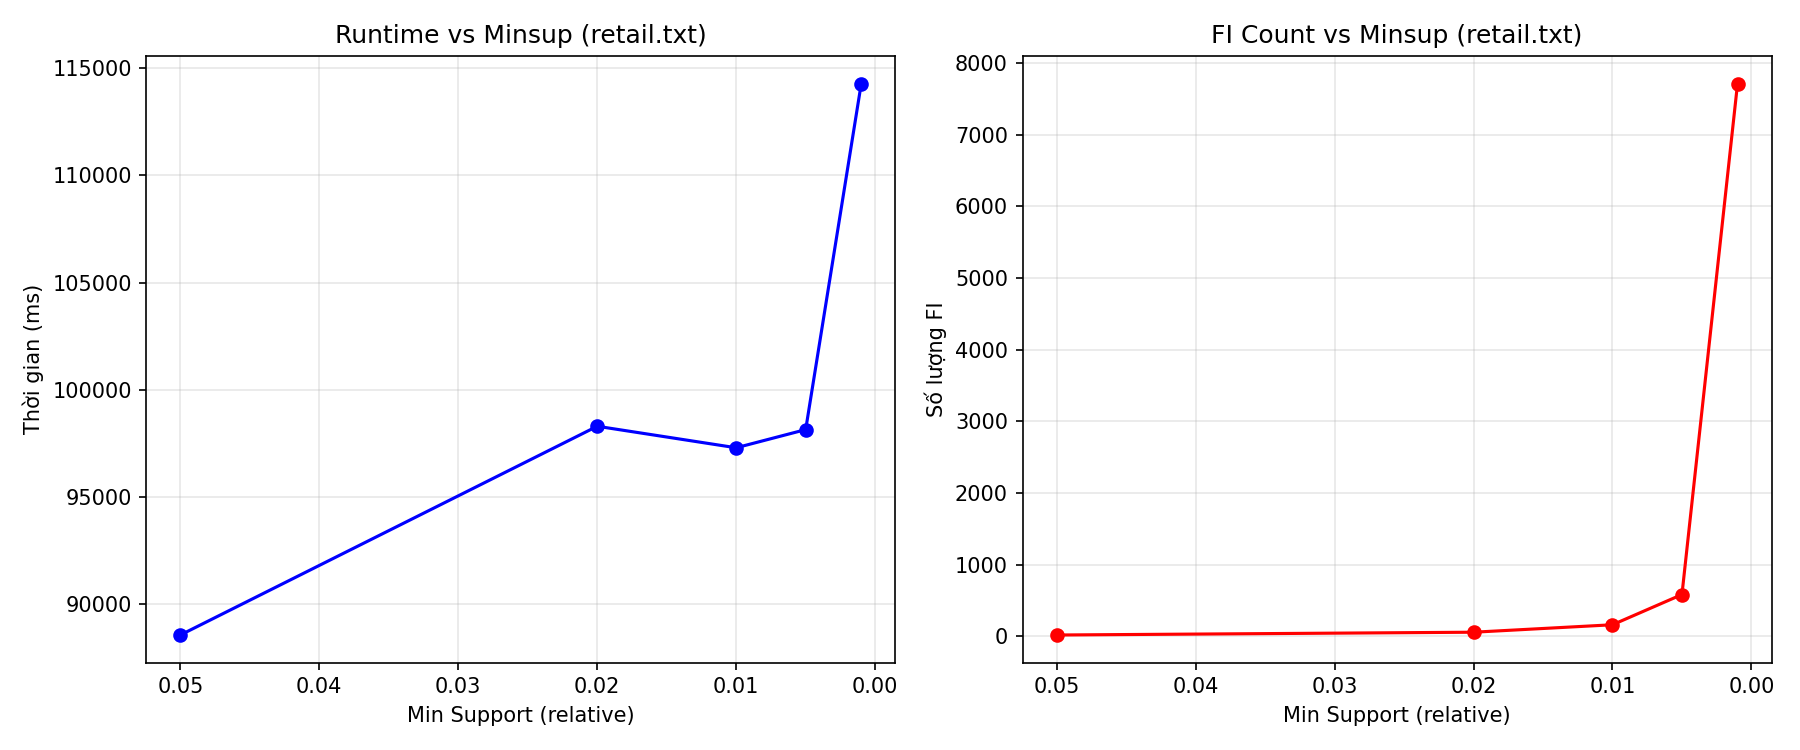

### `benchmark_T10I4D100K.png`

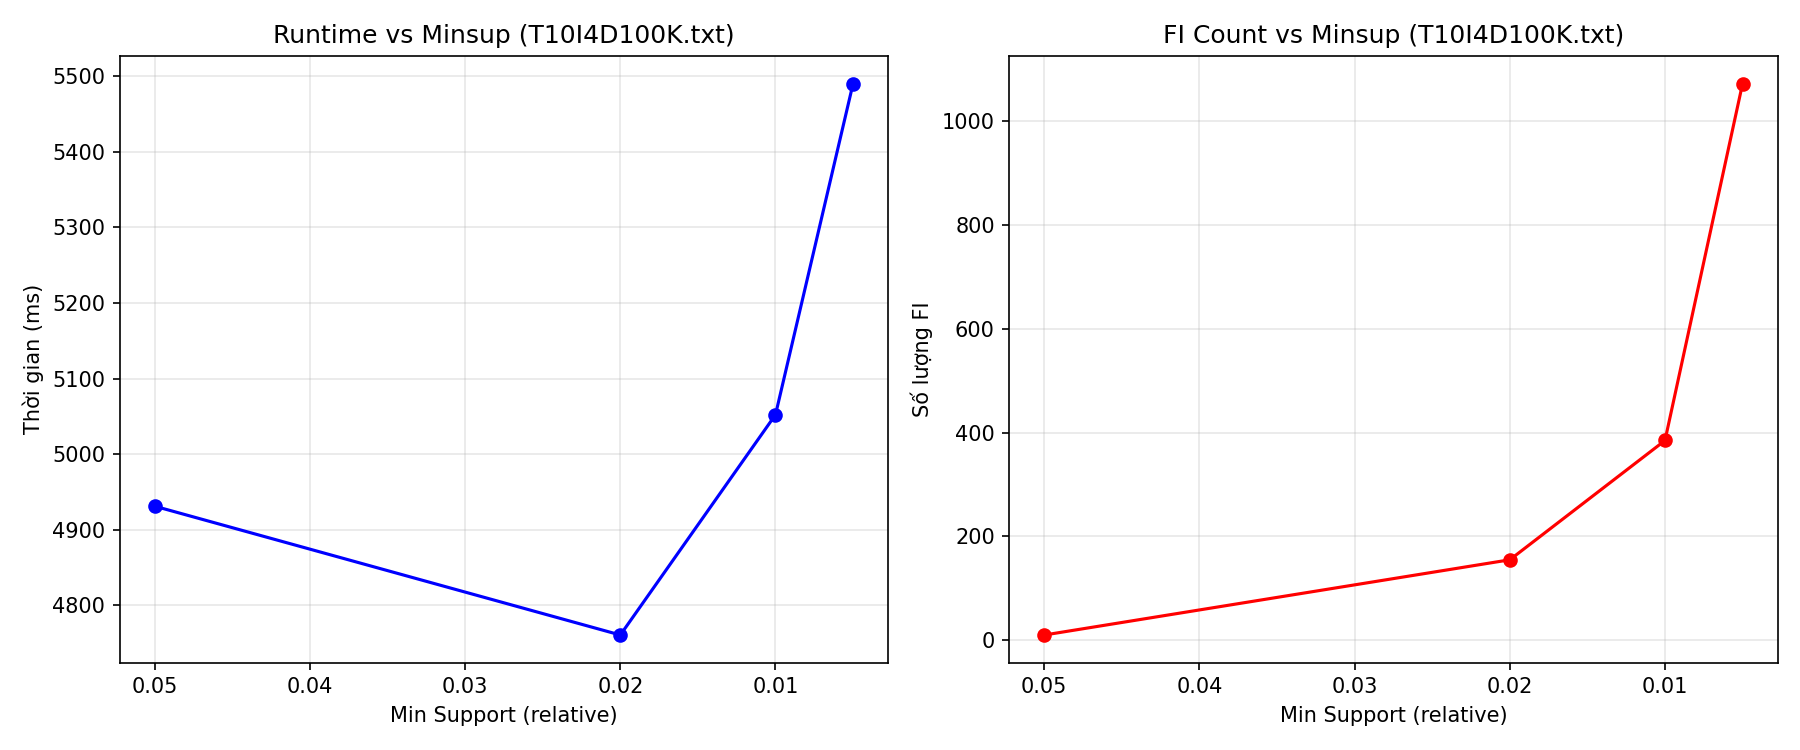

In [6]:
benchmark_meta = pd.DataFrame([
    {"dataset": "chess", "path": "data/benchmark/chess.txt", "transactions": 3196, "items": 75, "avg_len": 37.0, "characteristic": "dense"},
    {"dataset": "mushroom", "path": "data/benchmark/mushroom.txt", "transactions": 8416, "items": 119, "avg_len": 23.0, "characteristic": "dense"},
    {"dataset": "retail", "path": "data/benchmark/retail.txt", "transactions": 88162, "items": 16470, "avg_len": 10.3, "characteristic": "sparse"},
    {"dataset": "T10I4D100K", "path": "data/benchmark/T10I4D100K.txt", "transactions": 100000, "items": 870, "avg_len": 10.1, "characteristic": "synthetic sparse"},
])
display(benchmark_meta)

for image_name in [
    "runtime_vs_minsup_toy3.png",
    "scalability_synthetic.png",
    "benchmark_chess.png",
    "benchmark_mushroom.png",
    "benchmark_retail.png",
    "benchmark_T10I4D100K.png",
]:
    image_path = DOCS_DIR / image_name
    if image_path.exists():
        display(Markdown(f"### `{image_name}`"))
        display(Image(filename=str(image_path)))
    else:
        display(Markdown(f"- Chưa tìm thấy `{image_name}`"))


## 5. Những gì notebook này hỗ trợ cho báo cáo

Notebook hiện đã phù hợp hơn để nộp kèm repo vì:

- chạy được ngay cả khi mở từ thư mục `notebooks/`
- có ví dụ cơ sở và tình huống đặc biệt để hỗ trợ Chương 2
- có kiểm tra lại tính đúng đắn và minh họa bản tối ưu so với baseline
- dùng lại các biểu đồ benchmark sẵn có trong `docs/`

Tuy vậy, để đạt điểm cao theo rubric, nhóm vẫn cần trình bày các phần học thuật trong **`docs/Report.pdf`**: định nghĩa toán học, chứng minh tính chất Apriori, giả mã có chú thích, phân tích độ phức tạp, so sánh với SPMF, phân tích từng biểu đồ và đề xuất tối ưu hóa tiếp theo.
